# Masters London 2026 — Team EDA

Focuses on **recent form only** — change `MIN_DATE` in the first code cell.

Sections:
1. Setup & sample sizes
2. Map win rate heatmap
3. Permaban inference
4. Attack vs Defence per map
5. Overall stats table
6. Head-to-head matrix
7. Recent form (rolling win rate)
8. Single-team deep dive
---
**Predictive EDA — what factors predict a win?**

9. Elo replay setup
   - 9a. Elo difference vs actual win rate
   - 9b. Pistol round win rate vs map win rate
   - 9c. Series score distribution (2-0 vs 2-1)
   - 9d. Attack vs defence balance in winners vs losers
   - 9e. Recent form as a match win predictor
   - 9f. Cross-region vs same-region upset rates
   - 9g. Feature correlation summary

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
from collections import defaultdict
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

# Change this to adjust the lookback window
MIN_DATE = '2025-09-01'   # current season  <-- good default
# MIN_DATE = '2026-01-01' # last ~5 months (small samples)
# MIN_DATE = '2025-06-01' # last ~12 months

with open('../data/processed/raw_matches.json') as f:
    ALL_MATCHES = json.load(f)

print(f'Total matches: {len(ALL_MATCHES)}')
print(f'Lookback: {MIN_DATE} onwards')

# LEVIATÁN is stored with U+00C1 (capital A with acute) in the scraped JSON
LEVIATAN = 'LEVIAT' + chr(0x00C1) + 'N'

ML_TEAMS = [
    'G2 Esports',  LEVIATAN,        'NRG',
    'Team Heretics','Team Vitality', 'FUT Esports',
    'Paper Rex',   'FULL SENSE',    'Global Esports',
    'EDward Gaming','Xi Lai Gaming', 'Dragon Ranger Gaming',
]

DISPLAY = {t: t for t in ML_TEAMS}
DISPLAY[LEVIATAN] = 'LEVIATÁN'

REGION = {
    'G2 Esports': 'Americas', LEVIATAN: 'Americas',        'NRG': 'Americas',
    'Team Heretics': 'EMEA',  'Team Vitality': 'EMEA',     'FUT Esports': 'EMEA',
    'Paper Rex': 'Pacific',   'FULL SENSE': 'Pacific',     'Global Esports': 'Pacific',
    'EDward Gaming': 'China', 'Xi Lai Gaming': 'China',    'Dragon Ranger Gaming': 'China',
}

REGION_COLORS = {
    'Americas': '#e74c3c', 'EMEA': '#3498db',
    'Pacific':  '#2ecc71', 'China': '#f39c12',
}

CURRENT_POOL = ['Haven', 'Lotus', 'Split', 'Pearl', 'Ascent', 'Breeze', 'Fracture']

def get_matches(team, min_date=MIN_DATE):
    out = []
    for m in ALL_MATCHES:
        if not m.get('date') or m['date'] < min_date: continue
        if m['team_a'] == team:   out.append((m, 'a'))
        elif m['team_b'] == team: out.append((m, 'b'))
    return sorted(out, key=lambda x: x[0]['date'])

print()
print(f"{'Team':<28} {'Region':<10} {'Series':>7}")
print('-' * 48)
for t in ML_TEAMS:
    n = len(get_matches(t))
    flag = '  low' if n < 10 else ''
    print(f"{DISPLAY[t]:<28} {REGION[t]:<10} {n:>7}{flag}")


Total matches: 1910
Lookback: 2025-09-01 onwards

Team                         Region      Series
------------------------------------------------
G2 Esports                   Americas        35
LEVIATÁN                     Americas        16
NRG                          Americas        30
Team Heretics                EMEA            28
Team Vitality                EMEA            26
FUT Esports                  EMEA            24
Paper Rex                    Pacific         38
FULL SENSE                   Pacific         32
Global Esports               Pacific         19
EDward Gaming                China           28
Xi Lai Gaming                China           21
Dragon Ranger Gaming         China           26


## 2. Map Win Rate Heatmap

In [2]:
def build_map_stats(team):
    raw = defaultdict(lambda: dict(played=0, wins=0, rwr=[], atk=[], dfn=[]))
    for match, side in get_matches(team):
        for mp in match.get('maps', []):
            name = mp.get('map', '')
            if not name or name == 'unknown': continue
            s = raw[name]
            s['played'] += 1
            if mp.get('winner_side') == side: s['wins'] += 1
            for key, lst in [('round_win_rate_' + side, s['rwr']),
                              ('atk_win_rate_' + side,   s['atk']),
                              ('def_win_rate_' + side,   s['dfn'])]:
                if key in mp: lst.append(mp[key])
    result = {}
    for name, s in raw.items():
        p = s['played']
        result[name] = dict(
            played=p, wins=s['wins'], losses=p - s['wins'],
            win_rate=s['wins'] / p if p else 0.5,
            avg_rwr=np.mean(s['rwr']) if s['rwr'] else 0.5,
            avg_atk=np.mean(s['atk']) if s['atk'] else 0.25,
            avg_def=np.mean(s['dfn']) if s['dfn'] else 0.25,
        )
    return result

ALL_STATS = {t: build_map_stats(t) for t in ML_TEAMS}

def ban_scores(team):
    total = len(get_matches(team))
    if total == 0: return {m: 0 for m in CURRENT_POOL}
    s = ALL_STATS[team]
    return {m: s.get(m, {}).get('played', 0) / total for m in CURRENT_POOL}

print('Map stats built.')


Map stats built.


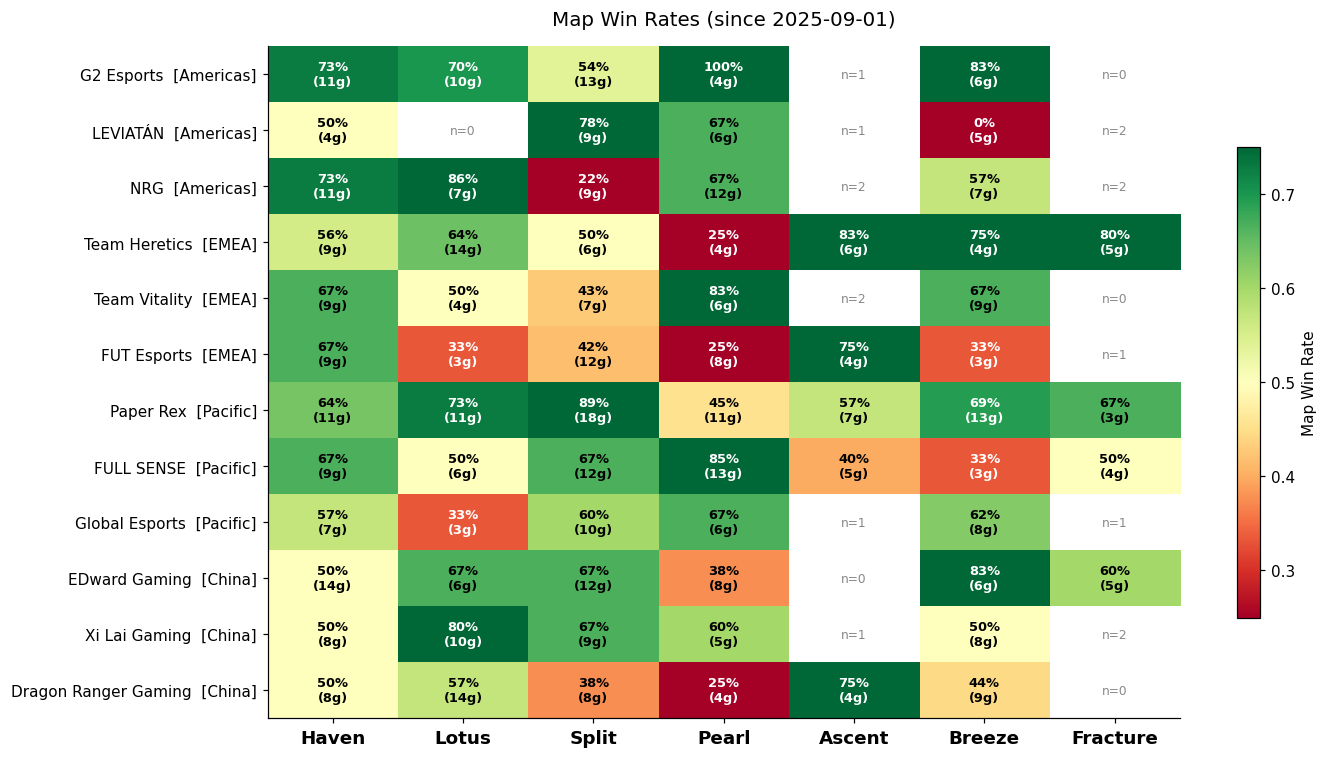

Green=dominant  Red=weak  n=X means fewer than 3 maps played


In [3]:
wr_data, pl_data = [], []
for t in ML_TEAMS:
    row_wr, row_pl = [], []
    for m in CURRENT_POOL:
        s = ALL_STATS[t].get(m)
        row_wr.append(s['win_rate'] if s and s['played'] >= 3 else float('nan'))
        row_pl.append(s['played']   if s else 0)
    wr_data.append(row_wr); pl_data.append(row_pl)

wr_df = pd.DataFrame(wr_data, index=[DISPLAY[t] for t in ML_TEAMS], columns=CURRENT_POOL)
pl_df = pd.DataFrame(pl_data, index=[DISPLAY[t] for t in ML_TEAMS], columns=CURRENT_POOL)

fig, ax = plt.subplots(figsize=(13, 7))
im = ax.imshow(wr_df.values, cmap='RdYlGn', vmin=0.25, vmax=0.75, aspect='auto')
ax.set_xticks(range(len(CURRENT_POOL)))
ax.set_xticklabels(CURRENT_POOL, fontsize=12, fontweight='bold')
ax.set_yticks(range(len(ML_TEAMS)))
ax.set_yticklabels([f"{DISPLAY[t]}  [{REGION[t]}]" for t in ML_TEAMS], fontsize=10)
for i, t in enumerate(ML_TEAMS):
    for j, mp in enumerate(CURRENT_POOL):
        wr = wr_df.iloc[i, j]; pl = pl_df.iloc[i, j]
        if wr != wr:
            ax.text(j, i, f'n={pl}', ha='center', va='center', fontsize=8, color='#888')
        else:
            ax.text(j, i, f'{wr:.0%}\n({pl}g)', ha='center', va='center',
                    fontsize=8.5, fontweight='bold',
                    color='white' if wr < 0.35 or wr > 0.68 else 'black')
plt.colorbar(im, ax=ax, label='Map Win Rate', shrink=0.7)
ax.set_title(f'Map Win Rates (since {MIN_DATE})', fontsize=13, pad=14)
plt.tight_layout(); plt.show()
print('Green=dominant  Red=weak  n=X means fewer than 3 maps played')


## 3. Permaban Inference

Shorter bar = team almost never plays this map = likely permaban.

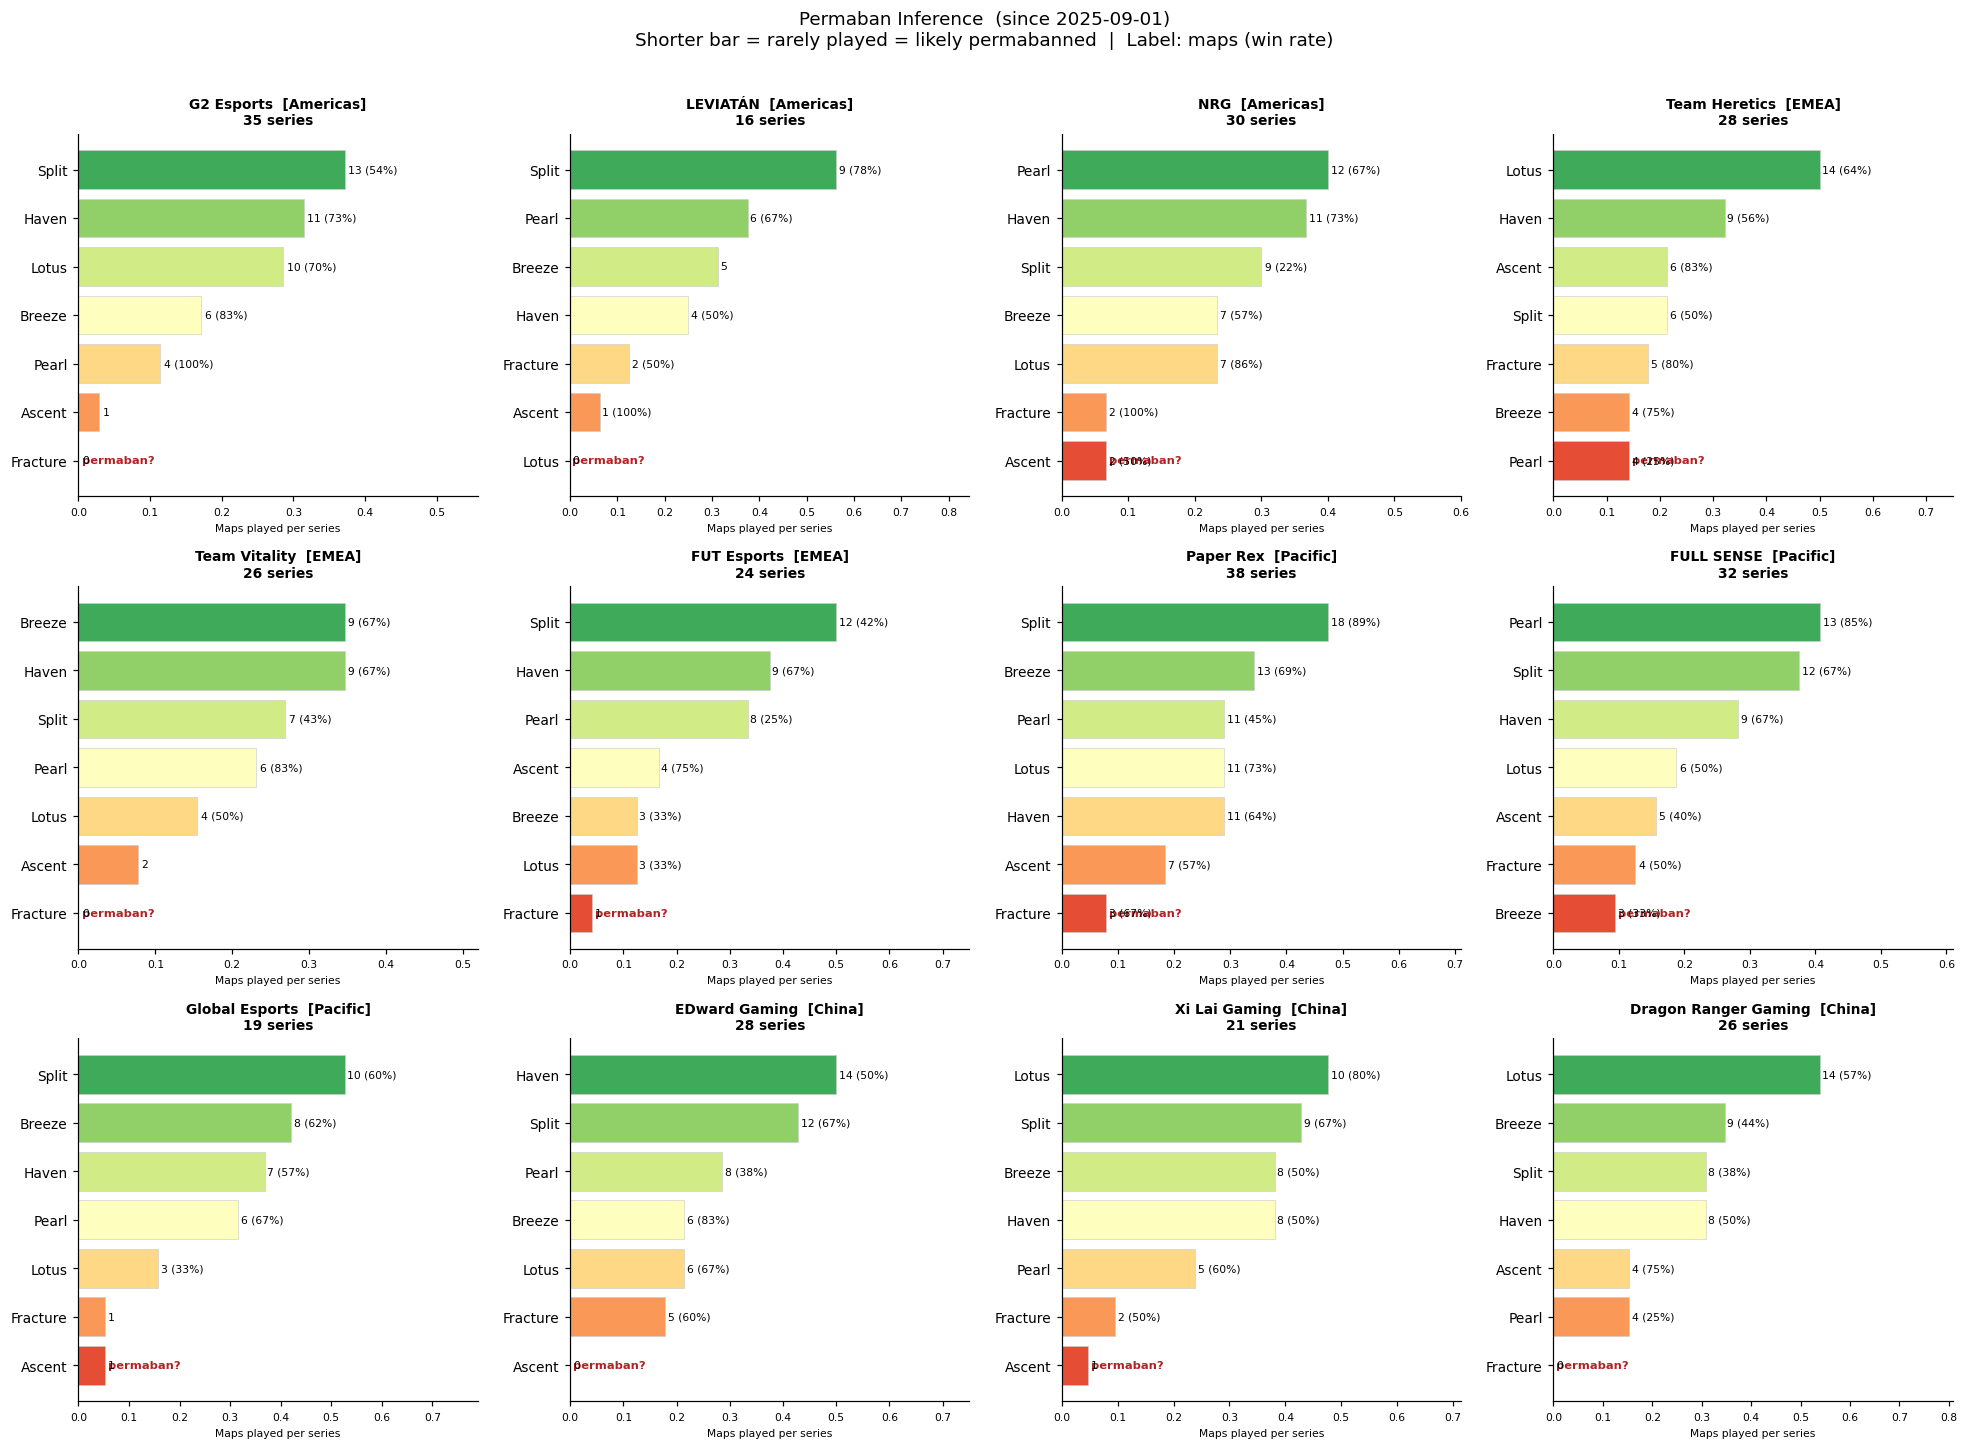

In [4]:
fig, axes = plt.subplots(3, 4, figsize=(18, 13))
axes = axes.flatten()
for idx, team in enumerate(ML_TEAMS):
    ax = axes[idx]
    scores = ban_scores(team)
    maps_s = sorted(CURRENT_POOL, key=lambda m: scores[m])
    vals   = [scores[m] for m in maps_s]
    colors = plt.cm.RdYlGn(np.linspace(0.15, 0.85, len(maps_s)))
    bars = ax.barh(maps_s, vals, color=colors, edgecolor='#ccc', linewidth=0.4)
    if vals and vals[-1] > 0 and vals[0] < vals[-1] * 0.4:
        ax.text(vals[0] + 0.005, 0, 'permaban?', va='center',
                fontsize=7.5, color='firebrick', fontweight='bold')
    for bar, m in zip(bars, maps_s):
        ms = ALL_STATS[team].get(m, {})
        pl = ms.get('played', 0)
        wr = ms.get('win_rate')
        label = str(pl) if not wr or pl == 0 else f'{pl} ({wr:.0%})'
        ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2,
                label, va='center', fontsize=7)
    n_series = len(get_matches(team))
    ax.set_title(f"{DISPLAY[team]}  [{REGION[team]}]\n{n_series} series",
                 fontsize=9, fontweight='bold')
    ax.set_xlabel('Maps played per series', fontsize=7)
    ax.set_xlim(0, max(vals) * 1.5 if any(v > 0 for v in vals) else 1)
    ax.tick_params(axis='y', labelsize=9); ax.tick_params(axis='x', labelsize=7)
plt.suptitle(
    f'Permaban Inference  (since {MIN_DATE})\n'
    'Shorter bar = rarely played = likely permabanned  |  Label: maps (win rate)',
    fontsize=12, y=1.01)
plt.tight_layout(); plt.show()


## 4. Attack vs Defence Strength per Map

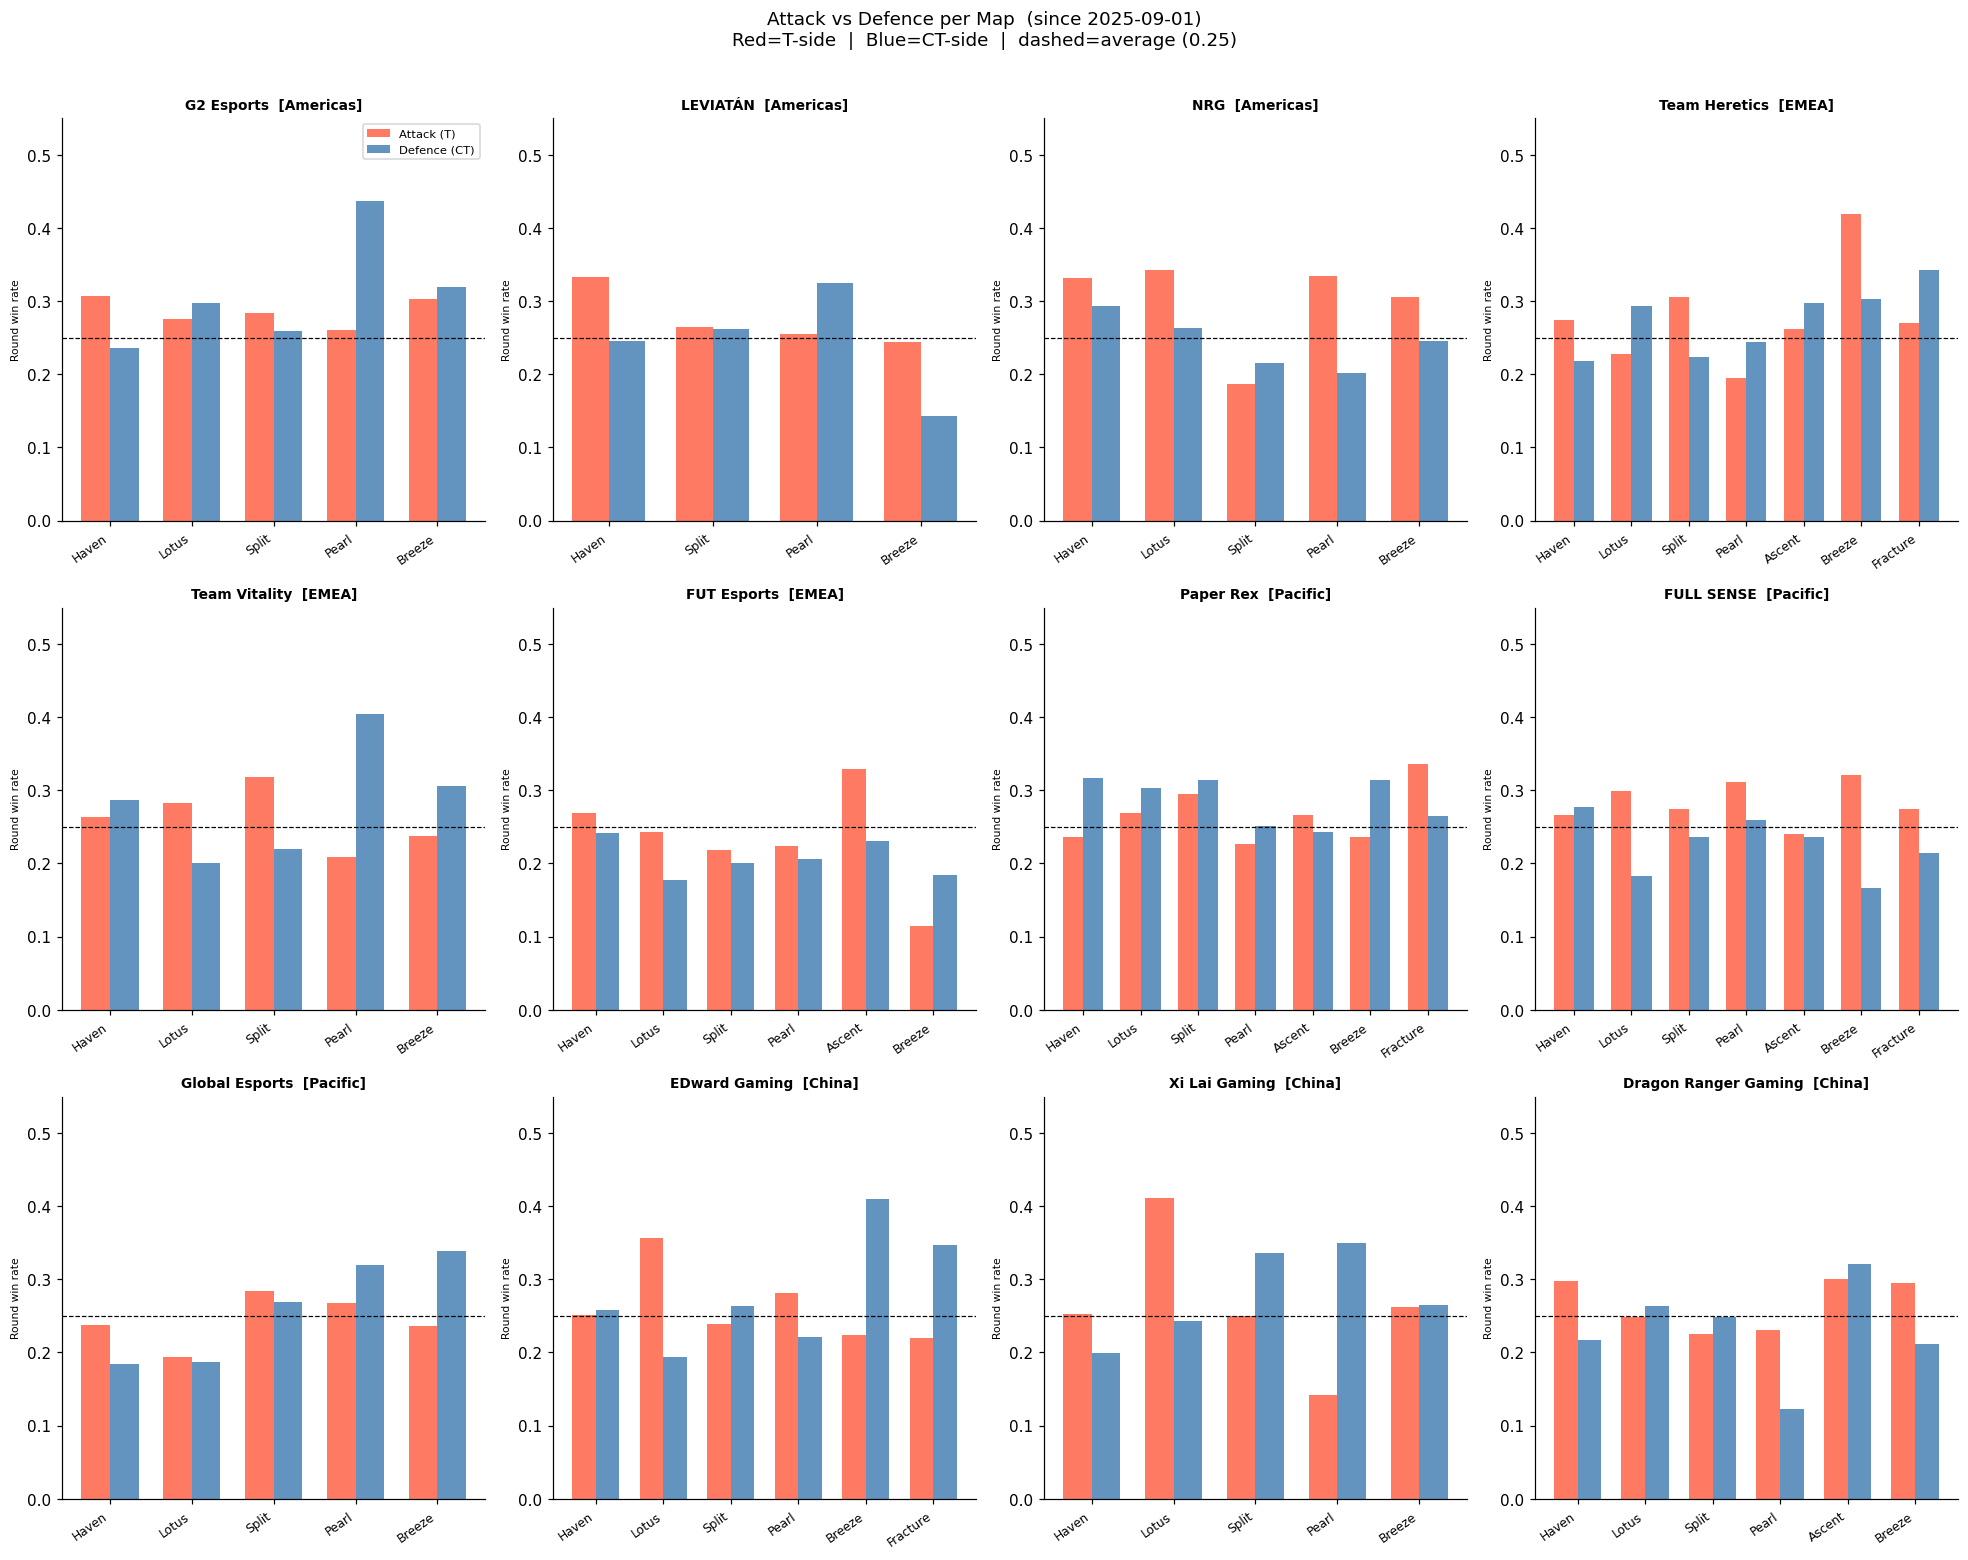

In [5]:
fig, axes = plt.subplots(3, 4, figsize=(18, 14))
axes = axes.flatten()
for idx, team in enumerate(ML_TEAMS):
    ax = axes[idx]
    s = ALL_STATS[team]
    maps_w = [m for m in CURRENT_POOL if m in s and s[m]['played'] >= 3]
    if not maps_w:
        ax.text(0.5, 0.5, 'insufficient data', ha='center', va='center',
                transform=ax.transAxes, color='gray')
        ax.set_title(DISPLAY[team], fontsize=9); continue
    x = np.arange(len(maps_w)); w = 0.35
    ax.bar(x - w/2, [s[m]['avg_atk'] for m in maps_w], w, label='Attack (T)',   color='tomato',    alpha=0.85)
    ax.bar(x + w/2, [s[m]['avg_def'] for m in maps_w], w, label='Defence (CT)', color='steelblue', alpha=0.85)
    ax.axhline(0.25, color='black', linestyle='--', linewidth=0.8)
    ax.set_xticks(x); ax.set_xticklabels(maps_w, rotation=35, ha='right', fontsize=8)
    ax.set_ylim(0, 0.55); ax.set_ylabel('Round win rate', fontsize=7)
    ax.set_title(f"{DISPLAY[team]}  [{REGION[team]}]", fontsize=9, fontweight='bold')
    if idx == 0: ax.legend(fontsize=7.5, loc='upper right')
plt.suptitle(
    f'Attack vs Defence per Map  (since {MIN_DATE})\n'
    'Red=T-side  |  Blue=CT-side  |  dashed=average (0.25)',
    fontsize=12, y=1.01)
plt.tight_layout(); plt.show()


## 5. Overall Stats Table

In [6]:
rows = []
for team in ML_TEAMS:
    matches = get_matches(team)
    n = len(matches)
    results = [int(m['winner'] == (0 if s == 'a' else 1)) for m, s in matches]
    w = sum(results)
    streak, streak_str = 0, '-'
    if results:
        last = results[-1]
        for r in reversed(results):
            if r == last: streak += 1
            else: break
        streak_str = f"W{streak}" if last == 1 else f"L{streak}"
    last5 = ''.join('W' if r == 1 else 'L' for r in results[-5:])
    ps = {m: ALL_STATS[team][m] for m in CURRENT_POOL
          if m in ALL_STATS[team] and ALL_STATS[team][m]['played'] >= 3}
    best  = max(ps, key=lambda m: ps[m]['win_rate']) if ps else '-'
    worst = min(ps, key=lambda m: ps[m]['win_rate']) if ps else '-'
    bs = ban_scores(team)
    pban = min(bs, key=bs.get) if bs else '-'
    rows.append({
        'Team':    DISPLAY[team],
        'Region':  REGION[team],
        'Series':  n,
        'W%':      f'{w/n:.0%}' if n else '-',
        'Last 5':  last5,
        'Streak':  streak_str,
        'Best map':  f"{best} ({ps[best]['win_rate']:.0%})" if best != '-' else '-',
        'Worst map': f"{worst} ({ps[worst]['win_rate']:.0%})" if worst != '-' else '-',
        'Likely ban': f"{pban} ({ALL_STATS[team].get(pban, {}).get('played', 0)}g)",
    })
df = pd.DataFrame(rows).set_index('Team')
print(df.to_string())


                        Region  Series   W% Last 5 Streak      Best map     Worst map     Likely ban
Team                                                                                                
G2 Esports            Americas      35  63%  WWWWW     W5  Pearl (100%)   Split (54%)  Fracture (0g)
LEVIATÁN              Americas      16  69%  WLLWW     W2   Split (78%)   Breeze (0%)     Lotus (0g)
NRG                   Americas      30  73%  WWWWW     W5   Lotus (86%)   Split (22%)    Ascent (2g)
Team Heretics             EMEA      28  57%  WWWWW     W5  Ascent (83%)   Pearl (25%)     Pearl (4g)
Team Vitality             EMEA      26  65%  WWWWL     L1   Pearl (83%)   Split (43%)  Fracture (0g)
FUT Esports               EMEA      24  58%  WLWLL     L2  Ascent (75%)   Pearl (25%)  Fracture (1g)
Paper Rex              Pacific      38  74%  LWWWW     W4   Split (89%)   Pearl (45%)  Fracture (3g)
FULL SENSE             Pacific      32  62%  LWWWL     L1   Pearl (85%)  Breeze (33%)    Br

## 6. Head-to-Head Between ML Teams

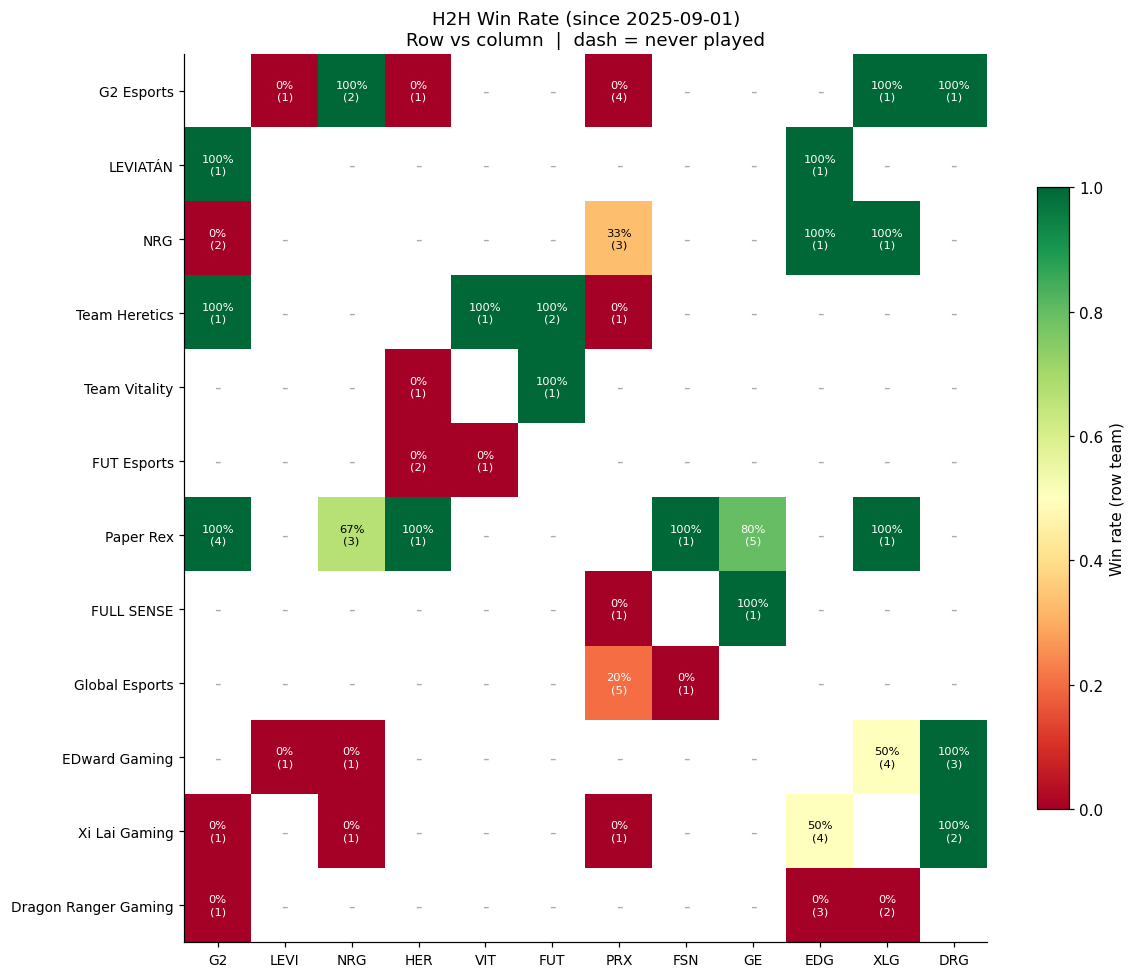

Most cross-region matchups are dash (never played in this window) -- normal.


In [7]:
n = len(ML_TEAMS); ti = {t: i for i, t in enumerate(ML_TEAMS)}
h2h_w = np.zeros((n, n)); h2h_cnt = np.zeros((n, n), dtype=int)
for m in ALL_MATCHES:
    if m.get('date', '') < MIN_DATE: continue
    ta, tb = m['team_a'], m['team_b']
    if ta not in ti or tb not in ti: continue
    i, j = ti[ta], ti[tb]
    h2h_cnt[i, j] += 1; h2h_cnt[j, i] += 1
    aw = (m['winner'] == 0)
    h2h_w[i, j] += int(aw); h2h_w[j, i] += int(not aw)
with np.errstate(invalid='ignore'):
    h2h_rate = np.where(h2h_cnt > 0, h2h_w / h2h_cnt, float('nan'))
short = ['G2','LEVI','NRG','HER','VIT','FUT','PRX','FSN','GE','EDG','XLG','DRG']
import numpy.ma as ma
fig, ax = plt.subplots(figsize=(11, 9))
masked = ma.masked_invalid(h2h_rate)
im = ax.imshow(masked, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto')
ax.set_xticks(range(n)); ax.set_xticklabels(short, fontsize=9)
ax.set_yticks(range(n)); ax.set_yticklabels([DISPLAY[t] for t in ML_TEAMS], fontsize=9)
ax.set_title(f'H2H Win Rate (since {MIN_DATE})\nRow vs column  |  dash = never played', fontsize=12)
for i in range(n):
    for j in range(n):
        if i == j: continue
        cnt = h2h_cnt[i, j]
        if cnt == 0:
            ax.text(j, i, '-', ha='center', va='center', fontsize=12, color='#aaa')
        else:
            wr = h2h_rate[i, j]
            ax.text(j, i, f'{wr:.0%}\n({cnt})', ha='center', va='center', fontsize=7.5,
                    color='white' if (wr < 0.25 or wr > 0.75) else 'black')
plt.colorbar(im, ax=ax, label='Win rate (row team)', shrink=0.7)
plt.tight_layout(); plt.show()
print('Most cross-region matchups are dash (never played in this window) -- normal.')


## 7. Recent Form

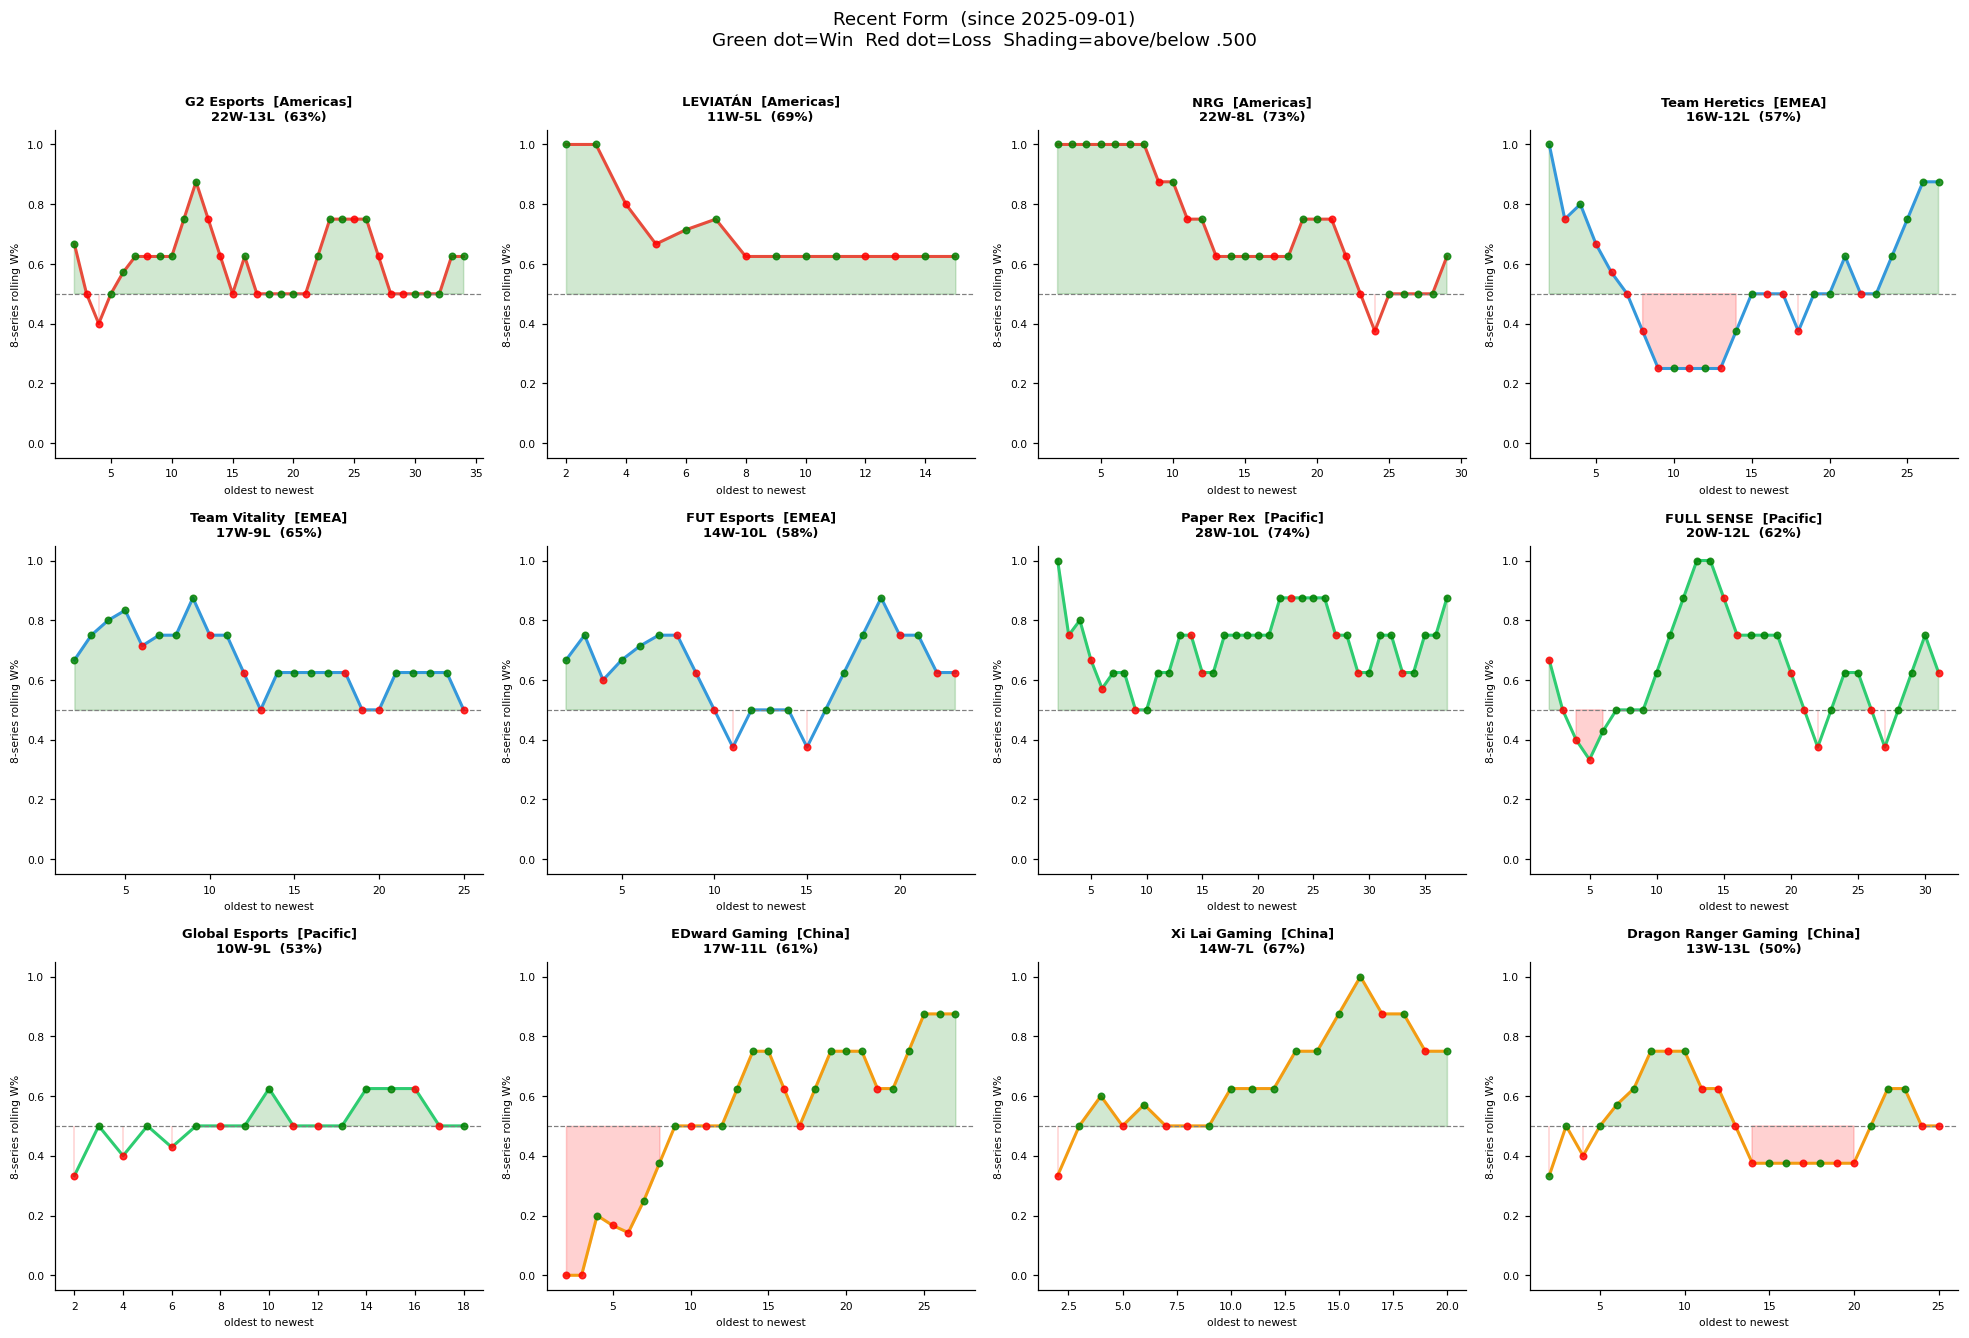

In [8]:
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()
for idx, team in enumerate(ML_TEAMS):
    ax = axes[idx]
    matches = get_matches(team)
    if not matches:
        ax.text(0.5, 0.5, 'no data', ha='center', va='center',
                transform=ax.transAxes, color='gray')
        ax.set_title(DISPLAY[team], fontsize=9); continue
    results = np.array([int(m['winner'] == (0 if s == 'a' else 1))
                        for m, s in matches], dtype=float)
    window  = min(8, len(results))
    rolling = pd.Series(results).rolling(window, min_periods=3).mean().values
    color = REGION_COLORS[REGION[team]]
    x = np.arange(len(rolling))
    ax.plot(x, rolling, color=color, linewidth=2)
    ax.fill_between(x, rolling, 0.5, where=(rolling >= 0.5), alpha=0.18, color='green')
    ax.fill_between(x, rolling, 0.5, where=(rolling <  0.5), alpha=0.18, color='red')
    ax.axhline(0.5, color='gray', linewidth=0.8, linestyle='--')
    for k, (res, rv) in enumerate(zip(results, rolling)):
        if rv == rv:
            ax.scatter(k, rv, color='green' if res == 1 else 'red', s=18, zorder=5, alpha=0.8)
    w = int(results.sum())
    ax.set_title(f"{DISPLAY[team]}  [{REGION[team]}]\n"
                 f"{w}W-{len(results)-w}L  ({results.mean():.0%})",
                 fontsize=8.5, fontweight='bold')
    ax.set_ylim(-0.05, 1.05)
    ax.set_ylabel(f'{window}-series rolling W%', fontsize=7)
    ax.set_xlabel('oldest to newest', fontsize=7)
    ax.tick_params(labelsize=7)
plt.suptitle(f'Recent Form  (since {MIN_DATE})\n'
             'Green dot=Win  Red dot=Loss  Shading=above/below .500',
             fontsize=12, y=1.01)
plt.tight_layout(); plt.show()


## 8. Single-team Deep Dive

Change `TEAM` to any of the 12 teams.

In [9]:
TEAM = 'Paper Rex'  # change this to any team name
                    # For LEVIATÁN, type 'LEVIATÁN' or 'LEVIATAN' -- handled automatically

if 'LEVIAT' in TEAM.upper():
    TEAM = LEVIATAN

stats   = ALL_STATS[TEAM]
matches = get_matches(TEAM)
results = [int(m['winner'] == (0 if s == 'a' else 1)) for m, s in matches]
n = len(results); w = sum(results)

print(f"\n{DISPLAY[TEAM]}  |  {REGION[TEAM]}  |  since {MIN_DATE}")
print(f"{w}W - {n-w}L  ({w/n:.1%})" if n else 'No data')
print('Last 5: ' + ' '.join('W' if r else 'L' for r in results[-5:]))
print()
print(f"  {'Map':<12} {'Played':>8} {'W-L':>6} {'Win%':>6} {'Rnd%':>7} {'Atk%':>7} {'Def%':>7}")
print('  ' + '-' * 58)
for m in sorted(CURRENT_POOL,
                key=lambda x: stats.get(x, {'win_rate': -1})['win_rate'],
                reverse=True):
    s = stats.get(m)
    if not s:
        print(f"  {m:<12} {'0':>8}  -- no data")
    else:
        wl = f"{s['wins']}-{s['losses']}"
        print(f"  {m:<12} {s['played']:>8} {wl:>6} {s['win_rate']:>6.0%}"
              f" {s['avg_rwr']:>7.0%} {s['avg_atk']:>7.0%} {s['avg_def']:>7.0%}")

bs = ban_scores(TEAM)
pban = min(bs, key=bs.get)
ppick = max(bs, key=bs.get)
print(f"\n  Likely permaban : {pban}  "
      f"({ALL_STATS[TEAM].get(pban, {}).get('played', 0)} maps played)")
print(f"  Likely pick     : {ppick}  "
      f"({ALL_STATS[TEAM].get(ppick, {}).get('played', 0)} maps  |  "
      f"{ALL_STATS[TEAM].get(ppick, {}).get('win_rate', 0):.0%} WR)")



Paper Rex  |  Pacific  |  since 2025-09-01
28W - 10L  (73.7%)
Last 5: L W W W W

  Map            Played    W-L   Win%    Rnd%    Atk%    Def%
  ----------------------------------------------------------
  Split              18   16-2    89%     62%     29%     31%
  Lotus              11    8-3    73%     57%     27%     30%
  Breeze             13    9-4    69%     55%     24%     31%
  Fracture            3    2-1    67%     61%     34%     27%
  Haven              11    7-4    64%     56%     24%     32%
  Ascent              7    4-3    57%     51%     27%     24%
  Pearl              11    5-6    45%     48%     23%     25%

  Likely permaban : Fracture  (3 maps played)
  Likely pick     : Split  (18 maps  |  89% WR)


---

## 9. What Predicts a Win? — Predictive EDA

Sections 1–8 described *how each team plays*. Sections 9+ ask: **which factors actually predict who wins?**

Questions explored:
- Does Elo gap reliably predict the outcome, and what is the upset rate by gap size?
- Do pistol rounds signal map wins?
- Are 2-0 sweeps associated with larger Elo gaps?
- Does attack vs defence dominance differ between map winners and losers?
- How well does recent form predict the next result?
- Are cross-region matches more or less predictable than same-region ones?

All sections use the **full historical dataset** (no `MIN_DATE` filter) to maximise sample size.

In [10]:
# ── Elo Replay (K=32, init=1500) — used throughout sections 9+ ───────────────
# Replay Elo from every match in date order, recording each team's rating
# *before* the match so we can compute pre-match Elo difference as a feature.

ELO_K    = 32
ELO_INIT = 1500

def elo_expected(ra, rb):
    return 1 / (1 + 10 ** ((rb - ra) / 400))

elo_live = defaultdict(lambda: ELO_INIT)
match_elos = []   # each entry = match dict + elo_a_pre / elo_b_pre

for m in sorted(ALL_MATCHES, key=lambda x: x.get('date', '')):
    ta, tb = m.get('team_a'), m.get('team_b')
    if not ta or not tb: continue
    ra, rb = elo_live[ta], elo_live[tb]
    match_elos.append({**m, 'elo_a_pre': ra, 'elo_b_pre': rb})
    exp_a  = elo_expected(ra, rb)
    win_a  = 1 if m.get('winner') == 0 else 0
    delta  = ELO_K * (win_a - exp_a)
    elo_live[ta] += delta
    elo_live[tb] -= delta

# Restrict to matches where both teams are ML teams
ml_set = set(ML_TEAMS)
ml_matches = [m for m in match_elos if m.get('team_a') in ml_set and m.get('team_b') in ml_set]

print(f"Total match records with Elo:   {len(match_elos)}")
print(f"ML-team-only matches:           {len(ml_matches)}")
print(f"\nFinal Elo ratings (ML teams, descending):")
for t in sorted(ML_TEAMS, key=lambda x: -elo_live[x]):
    print(f"  {DISPLAY[t]:<28} {elo_live[t]:.0f}")

Total match records with Elo:   1910
ML-team-only matches:           153

Final Elo ratings (ML teams, descending):
  Paper Rex                    1796
  NRG                          1728
  G2 Esports                   1718
  Team Heretics                1666
  EDward Gaming                1652
  FULL SENSE                   1642
  Xi Lai Gaming                1627
  LEVIATÁN                     1617
  Team Vitality                1616
  FUT Esports                  1568
  Global Esports               1558
  Dragon Ranger Gaming         1502


### 9a. Elo Difference vs Actual Win Rate

How reliably does the pre-match Elo gap predict the outcome?  
Matches are grouped into buckets by Elo difference (team_a − team_b).  
The dotted line shows the *expected* win rate from the Elo formula — a well-calibrated model would sit on that line.

Elo favourite wins: 63.6%  (all matches, ties excluded at diff=0)


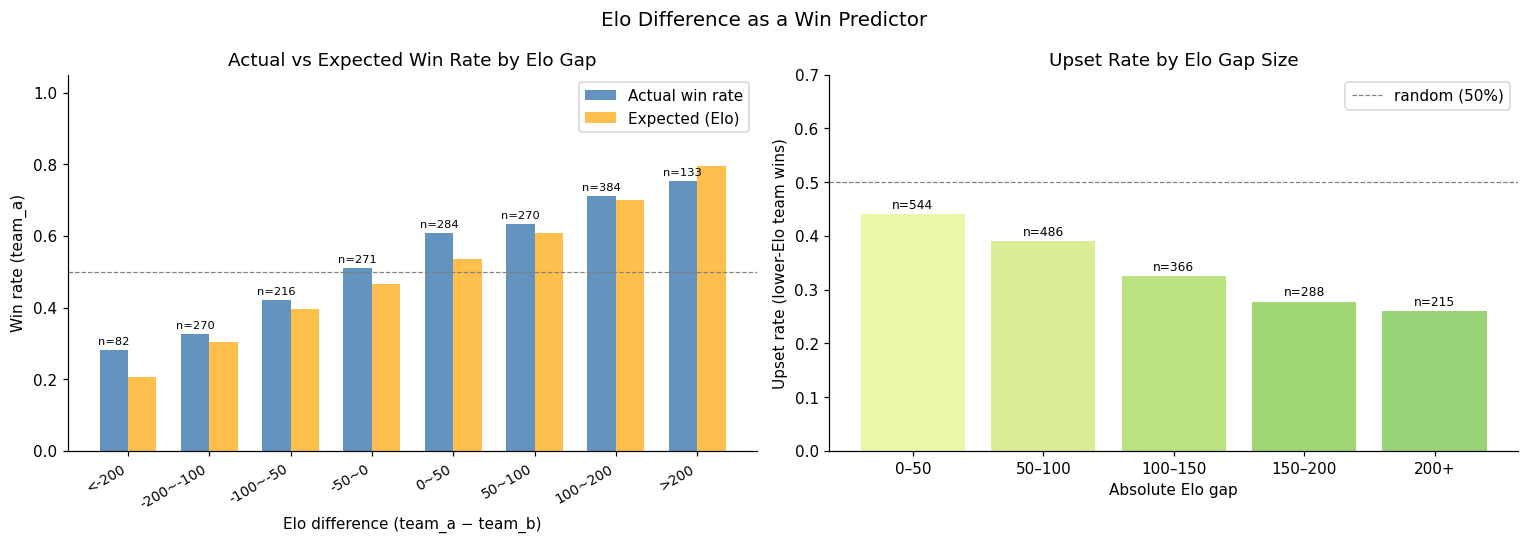

In [11]:
all_elo_rows = []
for m in match_elos:
    ta, tb = m.get('team_a'), m.get('team_b')
    if not ta or not tb: continue
    diff  = m['elo_a_pre'] - m['elo_b_pre']
    win_a = 1 if m.get('winner') == 0 else 0
    exp_a = elo_expected(m['elo_a_pre'], m['elo_b_pre'])
    all_elo_rows.append({'diff': diff, 'win': win_a, 'expected': exp_a})

df_elo = pd.DataFrame(all_elo_rows)

# Bin by Elo diff
bins   = [-600, -200, -100, -50, 0, 50, 100, 200, 600]
labels = ['<-200', '-200~-100', '-100~-50', '-50~0', '0~50', '50~100', '100~200', '>200']
df_elo['bucket'] = pd.cut(df_elo['diff'], bins=bins, labels=labels)
bucket_stats = df_elo.groupby('bucket', observed=True).agg(
    actual_wr=('win',      'mean'),
    expected_wr=('expected','mean'),
    n=('win', 'count'),
).reset_index()

# Overall Elo accuracy (favoured team wins?)
elo_correct = (df_elo['diff'] * (df_elo['win'] * 2 - 1) > 0).mean()
print(f"Elo favourite wins: {elo_correct:.1%}  (all matches, ties excluded at diff=0)")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: actual vs expected win rate by bucket
ax = axes[0]
x = np.arange(len(bucket_stats))
w = 0.35
bars = ax.bar(x - w/2, bucket_stats['actual_wr'],   w, label='Actual win rate',   color='steelblue', alpha=0.85)
ax.bar(       x + w/2, bucket_stats['expected_wr'], w, label='Expected (Elo)',     color='orange',    alpha=0.7)
for bar, n in zip(bars, bucket_stats['n']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f'n={n}', ha='center', va='bottom', fontsize=7.5)
ax.set_xticks(x)
ax.set_xticklabels(bucket_stats['bucket'], rotation=30, ha='right', fontsize=9)
ax.set_ylim(0, 1.05)
ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8)
ax.set_ylabel('Win rate (team_a)')
ax.set_xlabel('Elo difference (team_a − team_b)')
ax.set_title('Actual vs Expected Win Rate by Elo Gap')
ax.legend()

# Right: upset rate by absolute Elo gap
bins2  = [0, 50, 100, 150, 200, 600]
labels2 = ['0–50', '50–100', '100–150', '150–200', '200+']
df_elo2 = df_elo[df_elo['diff'] != 0].copy()
df_elo2['abs_diff'] = df_elo2['diff'].abs()
df_elo2['upset']    = ((df_elo2['diff'] > 0) & (df_elo2['win'] == 0)) | \
                      ((df_elo2['diff'] < 0) & (df_elo2['win'] == 1))
df_elo2['gap_bucket'] = pd.cut(df_elo2['abs_diff'], bins=bins2, labels=labels2)
upset_stats = df_elo2.groupby('gap_bucket', observed=True).agg(
    upset_rate=('upset', 'mean'), n=('upset', 'count')).reset_index()

ax2 = axes[1]
bars2 = ax2.bar(range(len(upset_stats)), upset_stats['upset_rate'],
                color=plt.cm.RdYlGn_r(upset_stats['upset_rate'].values), alpha=0.9)
for bar, n in zip(bars2, upset_stats['n']):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
             f'n={n}', ha='center', va='bottom', fontsize=8)
ax2.set_xticks(range(len(upset_stats)))
ax2.set_xticklabels(upset_stats['gap_bucket'], fontsize=10)
ax2.set_ylim(0, 0.7)
ax2.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, label='random (50%)')
ax2.set_ylabel('Upset rate (lower-Elo team wins)')
ax2.set_xlabel('Absolute Elo gap')
ax2.set_title('Upset Rate by Elo Gap Size')
ax2.legend()

plt.suptitle('Elo Difference as a Win Predictor', fontsize=13)
plt.tight_layout(); plt.show()

### 9b. Pistol Round Win Rate vs Map Win Rate

Pistol rounds open each half and give the winner an economic advantage.  
Do teams that win more pistols also win the map more often?  
We look at map-level data: for each team on each map, correlate their pistol win rate with their map win rate.

Map-level observations: 9202
Pearson r (pistol WR vs round WR): 0.454


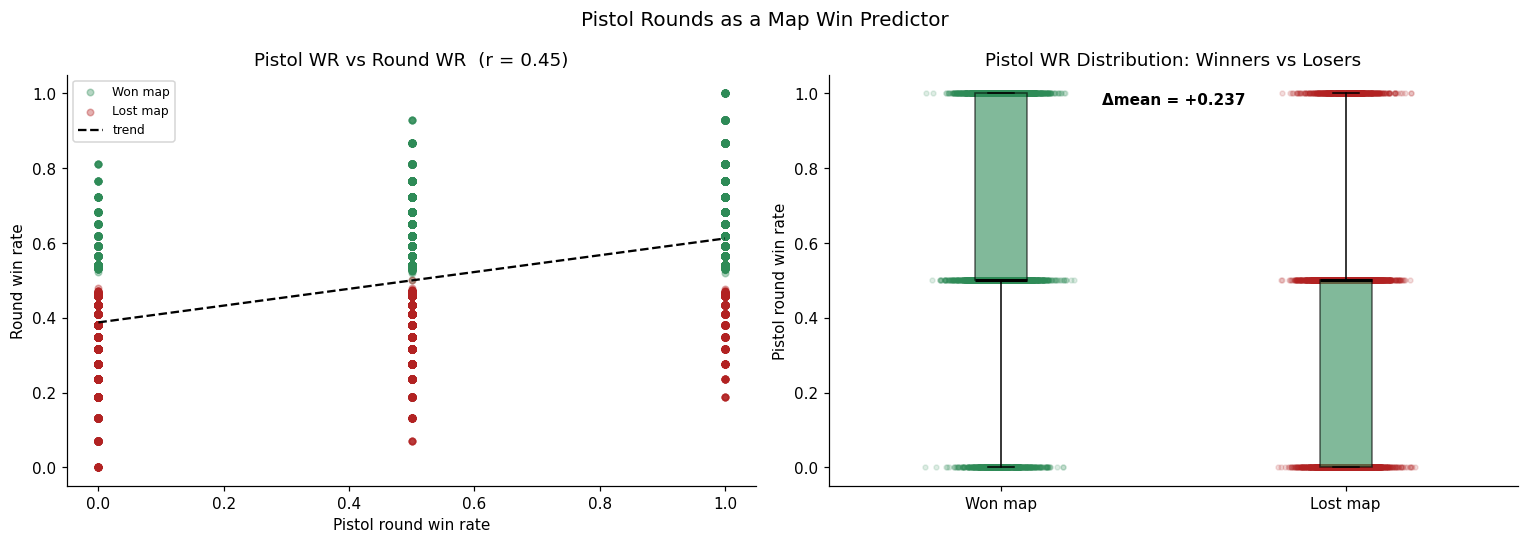


Team with higher pistol WR wins the map: 72.8%  (n=2390 maps)


In [12]:
map_level_rows = []

for m in ALL_MATCHES:
    ta, tb = m.get('team_a'), m.get('team_b')
    for mp in m.get('maps', []):
        name = mp.get('map', '')
        if not name or name == 'unknown': continue

        for side, opp in [('a', tb), ('b', ta)]:
            pwr  = mp.get(f'pistol_win_rate_{side}')
            rwr  = mp.get(f'round_win_rate_{side}')
            atk  = mp.get(f'atk_win_rate_{side}')
            dfn  = mp.get(f'def_win_rate_{side}')
            team = ta if side == 'a' else tb
            won  = 1 if mp.get('winner_side') == side else 0
            if pwr is None or rwr is None: continue
            map_level_rows.append({
                'team': team, 'map': name,
                'pistol_wr': pwr, 'round_wr': rwr,
                'atk_wr': atk, 'def_wr': dfn,
                'won_map': won,
            })

df_maps = pd.DataFrame(map_level_rows)
print(f"Map-level observations: {len(df_maps)}")

# Correlation: pistol_wr vs round_wr
corr = df_maps['pistol_wr'].corr(df_maps['round_wr'])
print(f"Pearson r (pistol WR vs round WR): {corr:.3f}")

# Did winner pistol > loser pistol?
df_maps_w = df_maps[df_maps['won_map'] == 1]['pistol_wr']
df_maps_l = df_maps[df_maps['won_map'] == 0]['pistol_wr']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: scatter pistol_wr vs round_wr, coloured by map outcome
ax = axes[0]
for won, color, label in [(1, 'seagreen', 'Won map'), (0, 'firebrick', 'Lost map')]:
    sub = df_maps[df_maps['won_map'] == won]
    ax.scatter(sub['pistol_wr'], sub['round_wr'], c=color, alpha=0.35, s=18, label=label)
ax.set_xlabel('Pistol round win rate')
ax.set_ylabel('Round win rate')
ax.set_title(f'Pistol WR vs Round WR  (r = {corr:.2f})')
# trend line
z = np.polyfit(df_maps['pistol_wr'], df_maps['round_wr'], 1)
px = np.linspace(df_maps['pistol_wr'].min(), df_maps['pistol_wr'].max(), 100)
ax.plot(px, np.polyval(z, px), color='black', linewidth=1.5, linestyle='--', label='trend')
ax.legend(fontsize=8)

# Right: box plot pistol_wr by map outcome
ax2 = axes[1]
ax2.boxplot([df_maps_w.values, df_maps_l.values],
            labels=['Won map', 'Lost map'],
            patch_artist=True,
            boxprops=dict(facecolor='seagreen', alpha=0.6),
            medianprops=dict(color='black', linewidth=2))
# overlay stripped jitter
for i, (group, c) in enumerate([(df_maps_w, 'seagreen'), (df_maps_l, 'firebrick')], 1):
    ax2.scatter(np.random.normal(i, 0.06, size=len(group)), group.values,
                alpha=0.15, s=10, color=c)
ax2.set_ylabel('Pistol round win rate')
ax2.set_title('Pistol WR Distribution: Winners vs Losers')
diff_mean = df_maps_w.mean() - df_maps_l.mean()
ax2.text(1.5, df_maps['pistol_wr'].max() * 0.97,
         f'Δmean = +{diff_mean:.3f}', ha='center', fontsize=10, fontweight='bold')

plt.suptitle('Pistol Rounds as a Map Win Predictor', fontsize=13)
plt.tight_layout(); plt.show()

# How often does the team with more pistols win the map?
# Match maps: pair team_a and team_b observations for same map instance
pistol_rows = []
for m in ALL_MATCHES:
    for mp in m.get('maps', []):
        name = mp.get('map', '')
        if not name or name == 'unknown': continue
        pa = mp.get('pistol_win_rate_a'); pb = mp.get('pistol_win_rate_b')
        ws = mp.get('winner_side')
        if pa is None or pb is None or not ws: continue
        if pa == pb: continue
        higher_wins = int((pa > pb and ws == 'a') or (pa < pb and ws == 'b'))
        pistol_rows.append(higher_wins)

pct = np.mean(pistol_rows)
print(f"\nTeam with higher pistol WR wins the map: {pct:.1%}  (n={len(pistol_rows)} maps)")

### 9c. Series Score Distribution — 2-0 Sweeps vs 2-1 Comebacks

A 2-0 sweep means the winner dominated both maps. A 2-1 finish means the loser won at least one map.  
Does a larger Elo gap mean more sweeps? Are upsets more likely to go 2-1?

Total series: 1601
  2-0 sweeps : 960  (60.0%)
  2-1 series : 641  (40.0%)


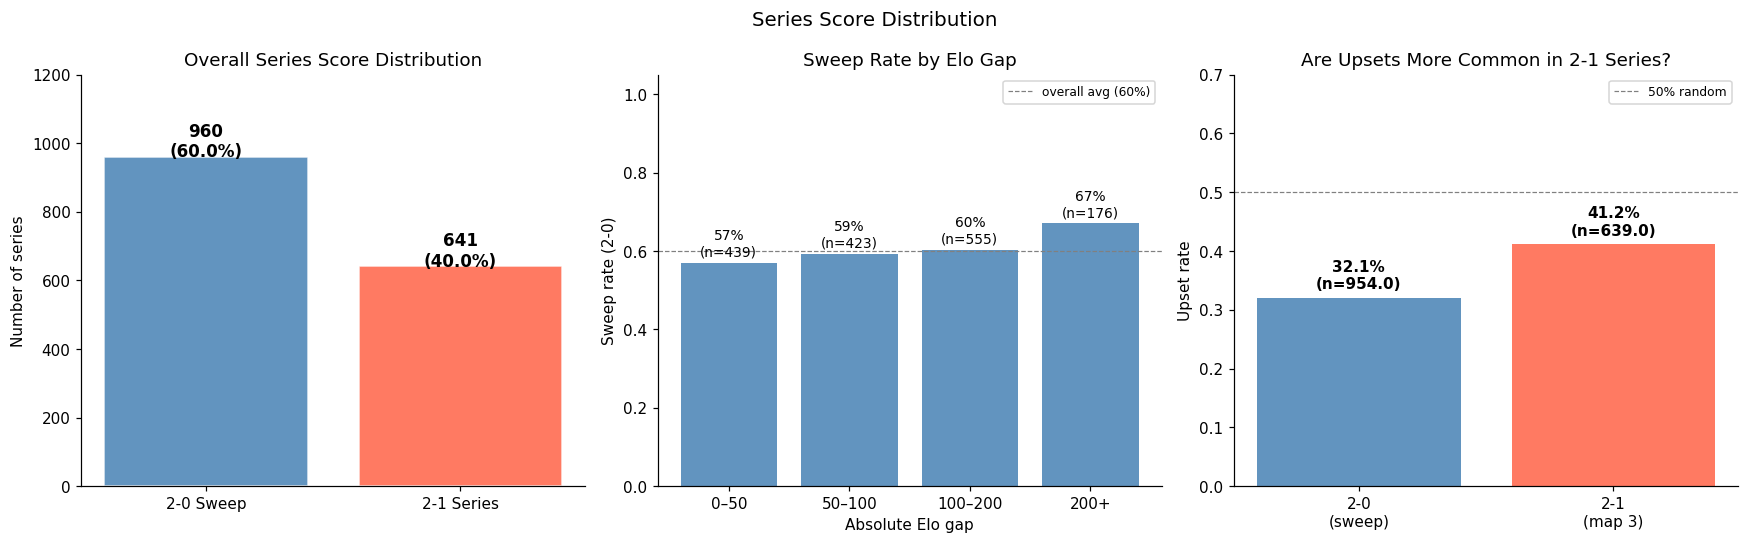

In [13]:
series_rows = []
for m in match_elos:
    sa = m.get('score_a', 0); sb = m.get('score_b', 0)
    if sa is None or sb is None: continue
    maps_played = sa + sb
    if maps_played not in (2, 3): continue  # expect best-of-3 (2-0 or 2-1)

    diff = m['elo_a_pre'] - m['elo_b_pre']
    win_a = 1 if m.get('winner') == 0 else 0
    upset = int((diff > 0 and win_a == 0) or (diff < 0 and win_a == 1))

    series_rows.append({
        'score': f"{max(sa,sb)}-{min(sa,sb)}",
        'maps_played': maps_played,
        'sweep': int(maps_played == 2),
        'elo_diff_abs': abs(diff),
        'upset': upset,
        'elo_diff': diff,
    })

df_series = pd.DataFrame(series_rows)
total = len(df_series)
n_20 = (df_series['maps_played'] == 2).sum()
n_21 = (df_series['maps_played'] == 3).sum()
print(f"Total series: {total}")
print(f"  2-0 sweeps : {n_20}  ({n_20/total:.1%})")
print(f"  2-1 series : {n_21}  ({n_21/total:.1%})")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Left: overall pie / bar
ax = axes[0]
ax.bar(['2-0 Sweep', '2-1 Series'], [n_20, n_21],
       color=['steelblue', 'tomato'], alpha=0.85, edgecolor='white')
for i, v in enumerate([n_20, n_21]):
    ax.text(i, v + 0.3, f'{v}\n({v/total:.1%})', ha='center', fontsize=11, fontweight='bold')
ax.set_ylabel('Number of series')
ax.set_title('Overall Series Score Distribution')
ax.set_ylim(0, max(n_20, n_21) * 1.25)

# Middle: sweep rate by Elo gap bucket
bins3   = [0, 50, 100, 200, 600]
labels3 = ['0–50', '50–100', '100–200', '200+']
df_series['gap_bucket'] = pd.cut(df_series['elo_diff_abs'], bins=bins3, labels=labels3)
sweep_by_gap = df_series.groupby('gap_bucket', observed=True).agg(
    sweep_rate=('sweep', 'mean'), n=('sweep', 'count')).reset_index()

ax2 = axes[1]
bars = ax2.bar(range(len(sweep_by_gap)), sweep_by_gap['sweep_rate'],
               color='steelblue', alpha=0.85)
for bar, (_, row) in zip(bars, sweep_by_gap.iterrows()):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{row.sweep_rate:.0%}\n(n={row.n})', ha='center', va='bottom', fontsize=9)
ax2.set_xticks(range(len(sweep_by_gap)))
ax2.set_xticklabels(sweep_by_gap['gap_bucket'], fontsize=10)
ax2.set_ylim(0, 1.05)
ax2.axhline(n_20/total, color='gray', linestyle='--', linewidth=0.8, label=f'overall avg ({n_20/total:.0%})')
ax2.set_ylabel('Sweep rate (2-0)')
ax2.set_xlabel('Absolute Elo gap')
ax2.set_title('Sweep Rate by Elo Gap')
ax2.legend(fontsize=8)

# Right: upset rate by series length
upset_by_len = df_series[df_series['elo_diff_abs'] > 0].groupby('maps_played').agg(
    upset_rate=('upset', 'mean'), n=('upset', 'count')).reset_index()

ax3 = axes[2]
labels_len = {2: '2-0\n(sweep)', 3: '2-1\n(map 3)'}
colors_len = {2: 'steelblue', 3: 'tomato'}
for _, row in upset_by_len.iterrows():
    ax3.bar(labels_len[row.maps_played], row.upset_rate,
            color=colors_len[row.maps_played], alpha=0.85)
    ax3.text(list(labels_len.values()).index(labels_len[row.maps_played]),
             row.upset_rate + 0.01, f'{row.upset_rate:.1%}\n(n={row.n})',
             ha='center', va='bottom', fontsize=10, fontweight='bold')
ax3.set_ylim(0, 0.7)
ax3.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, label='50% random')
ax3.set_ylabel('Upset rate')
ax3.set_title('Are Upsets More Common in 2-1 Series?')
ax3.legend(fontsize=8)

plt.suptitle('Series Score Distribution', fontsize=13)
plt.tight_layout(); plt.show()

### 9d. Attack vs Defence Balance in Map Winners vs Losers

Do winning teams tend to be CT-dominant, T-dominant, or balanced?  
We compare the average attack and defence win rates for the map winner vs the map loser across all maps.

Winners  — avg atk: 0.318  avg def: 0.315  imbalance (atk−def): +0.003
Losers   — avg atk: 0.178  avg def: 0.172  imbalance (atk−def): +0.006


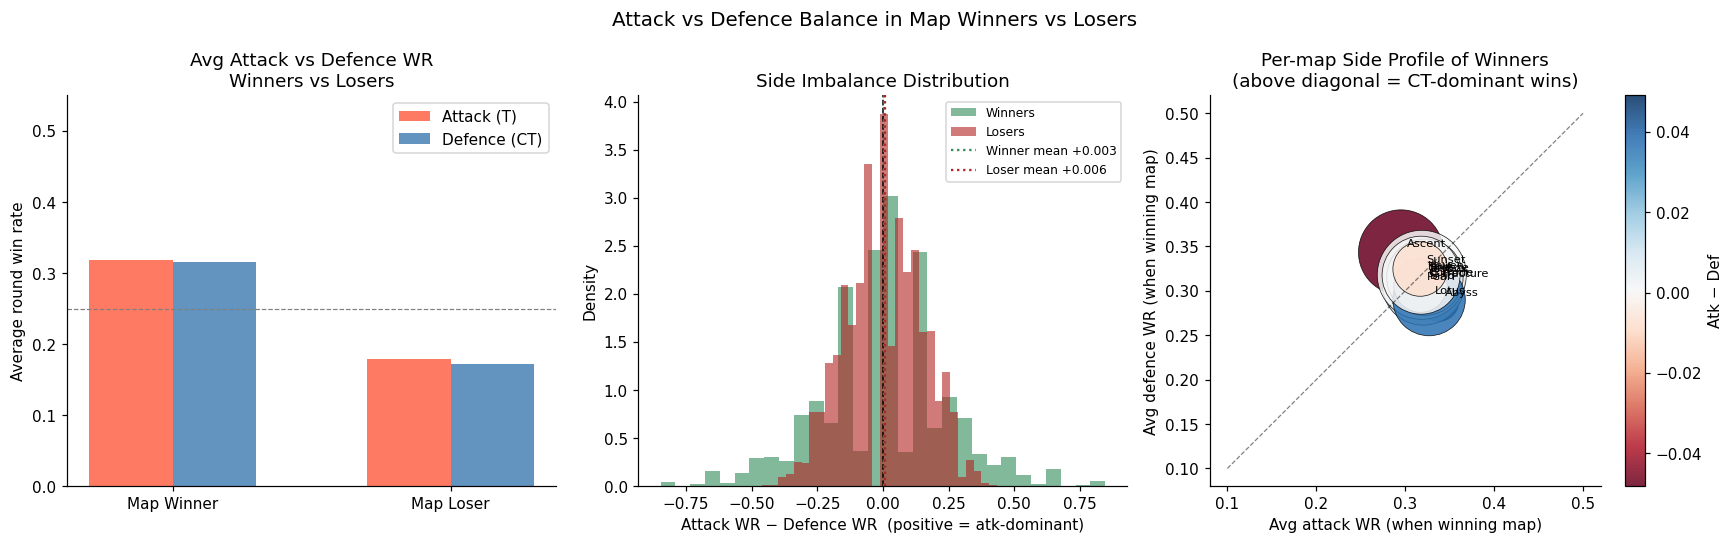

In [14]:
winner_atk, winner_def = [], []
loser_atk,  loser_def  = [], []
# imbalance = atk - def for winners and losers
winner_imbalance, loser_imbalance = [], []

for row in df_maps.itertuples():
    a, d = row.atk_wr, row.def_wr
    if a is None or d is None: continue
    if row.won_map == 1:
        winner_atk.append(a); winner_def.append(d)
        winner_imbalance.append(a - d)
    else:
        loser_atk.append(a); loser_def.append(d)
        loser_imbalance.append(a - d)

print(f"Winners  — avg atk: {np.mean(winner_atk):.3f}  avg def: {np.mean(winner_def):.3f}"
      f"  imbalance (atk−def): {np.mean(winner_imbalance):+.3f}")
print(f"Losers   — avg atk: {np.mean(loser_atk):.3f}  avg def: {np.mean(loser_def):.3f}"
      f"  imbalance (atk−def): {np.mean(loser_imbalance):+.3f}")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Left: grouped bars
ax = axes[0]
x = np.array([0, 1]); w = 0.3
ax.bar(x - w/2, [np.mean(winner_atk), np.mean(loser_atk)], w,
       label='Attack (T)', color='tomato', alpha=0.85)
ax.bar(x + w/2, [np.mean(winner_def), np.mean(loser_def)], w,
       label='Defence (CT)', color='steelblue', alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(['Map Winner', 'Map Loser'])
ax.set_ylim(0, 0.55); ax.axhline(0.25, color='gray', linestyle='--', linewidth=0.8)
ax.set_ylabel('Average round win rate')
ax.set_title('Avg Attack vs Defence WR\nWinners vs Losers')
ax.legend()

# Middle: imbalance distribution (atk − def) for winners vs losers
ax2 = axes[1]
ax2.hist(winner_imbalance, bins=30, alpha=0.6, color='seagreen', label='Winners', density=True)
ax2.hist(loser_imbalance,  bins=30, alpha=0.6, color='firebrick', label='Losers',  density=True)
ax2.axvline(0, color='black', linewidth=1, linestyle='--')
ax2.axvline(np.mean(winner_imbalance), color='seagreen', linewidth=1.5, linestyle=':',
            label=f'Winner mean {np.mean(winner_imbalance):+.3f}')
ax2.axvline(np.mean(loser_imbalance),  color='firebrick', linewidth=1.5, linestyle=':',
            label=f'Loser mean {np.mean(loser_imbalance):+.3f}')
ax2.set_xlabel('Attack WR − Defence WR  (positive = atk-dominant)')
ax2.set_ylabel('Density')
ax2.set_title('Side Imbalance Distribution')
ax2.legend(fontsize=8)

# Right: per-map scatter — winner avg_atk vs avg_def
# Aggregate per team per map for winners only
df_map_agg = df_maps[df_maps['won_map'] == 1].groupby('map').agg(
    avg_atk=('atk_wr', 'mean'), avg_def=('def_wr', 'mean'), n=('won_map', 'count')
).reset_index()

ax3 = axes[2]
sc = ax3.scatter(df_map_agg['avg_atk'], df_map_agg['avg_def'],
                 s=df_map_agg['n'] * 5, c=df_map_agg['avg_atk'] - df_map_agg['avg_def'],
                 cmap='RdBu', alpha=0.85, edgecolor='k', linewidth=0.5)
for _, row in df_map_agg.iterrows():
    ax3.annotate(row['map'], (row['avg_atk'], row['avg_def']),
                 textcoords='offset points', xytext=(4, 4), fontsize=7.5)
ax3.plot([0.1, 0.5], [0.1, 0.5], 'k--', linewidth=0.8, alpha=0.5)  # balance line
ax3.set_xlabel('Avg attack WR (when winning map)')
ax3.set_ylabel('Avg defence WR (when winning map)')
ax3.set_title('Per-map Side Profile of Winners\n(above diagonal = CT-dominant wins)')
plt.colorbar(sc, ax=ax3, label='Atk − Def')

plt.suptitle('Attack vs Defence Balance in Map Winners vs Losers', fontsize=13)
plt.tight_layout(); plt.show()

### 9e. Recent Form as a Match Win Predictor

For each match, we compute each team's rolling win rate over their last 5 series (before the match).  
If the team with better recent form wins more often, recent form is a useful feature.

Matches with form data: 1339
Team with better recent form wins: 60.6%  (excl. 234 ties)


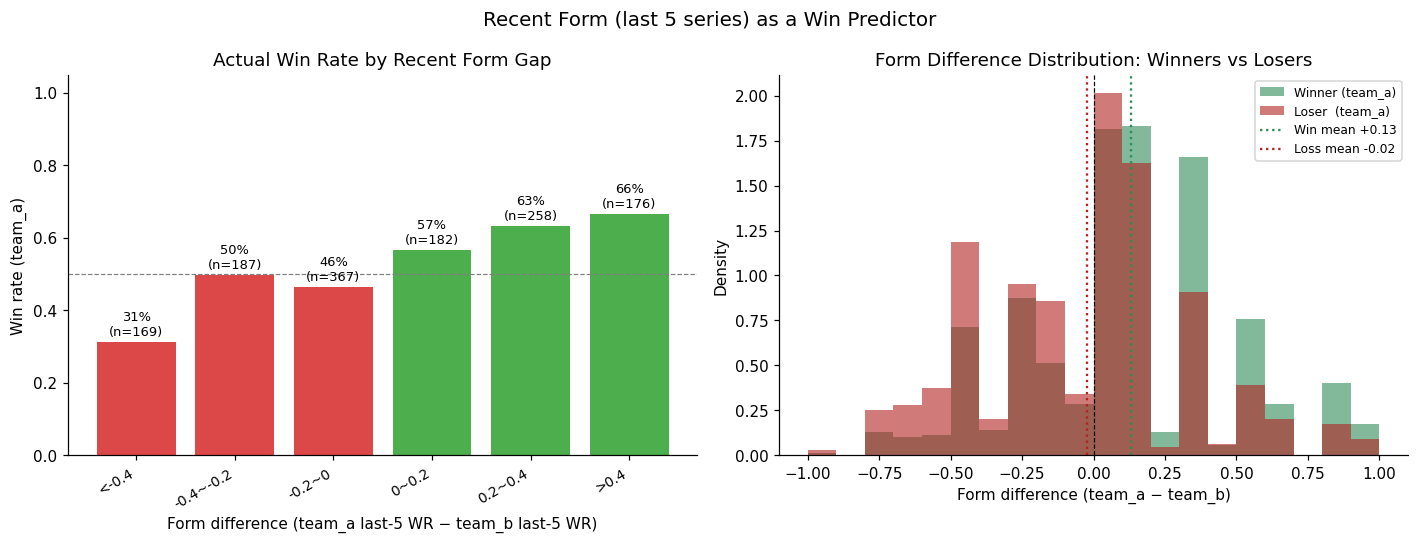

In [15]:
FORM_WINDOW = 5

# Build chronological win history for every team
team_history = defaultdict(list)  # team -> [(date, won)]

for m in sorted(ALL_MATCHES, key=lambda x: x.get('date', '')):
    ta, tb = m.get('team_a'), m.get('team_b')
    if not ta or not tb: continue
    win_a = (m.get('winner') == 0)
    team_history[ta].append((m['date'], int(win_a)))
    team_history[tb].append((m['date'], int(not win_a)))

def rolling_form(team, before_date, window=FORM_WINDOW):
    hist = [r for d, r in team_history[team] if d < before_date]
    if len(hist) < 2: return None  # need at least 2 results
    recent = hist[-window:]
    return sum(recent) / len(recent)

form_rows = []
for m in sorted(ALL_MATCHES, key=lambda x: x.get('date', '')):
    ta, tb = m.get('team_a'), m.get('team_b')
    date   = m.get('date', '')
    if not ta or not tb or not date: continue
    fa = rolling_form(ta, date)
    fb = rolling_form(tb, date)
    if fa is None or fb is None: continue
    win_a = 1 if m.get('winner') == 0 else 0
    form_rows.append({'form_a': fa, 'form_b': fb,
                      'form_diff': fa - fb, 'win_a': win_a})

df_form = pd.DataFrame(form_rows)
print(f"Matches with form data: {len(df_form)}")

# Accuracy: did the team with better recent form win?
better_form_wins = ((df_form['form_diff'] > 0) & (df_form['win_a'] == 1)) | \
                   ((df_form['form_diff'] < 0) & (df_form['win_a'] == 0))
tied = df_form['form_diff'] == 0
acc = better_form_wins[~tied].mean()
print(f"Team with better recent form wins: {acc:.1%}  (excl. {tied.sum()} ties)")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: actual win rate by form_diff bucket
bins_f   = [-1.01, -0.4, -0.2, 0, 0.2, 0.4, 1.01]
labels_f = ['<-0.4', '-0.4~-0.2', '-0.2~0', '0~0.2', '0.2~0.4', '>0.4']
df_form['bucket'] = pd.cut(df_form['form_diff'], bins=bins_f, labels=labels_f)
fbucket = df_form.groupby('bucket', observed=True).agg(
    actual_wr=('win_a', 'mean'), n=('win_a', 'count')).reset_index()

ax = axes[0]
colors_f = ['#d62728' if float(c.split('~')[0].replace('<','').replace('>','')) < 0
            else '#2ca02c' for c in fbucket['bucket'].astype(str)]
bars = ax.bar(range(len(fbucket)), fbucket['actual_wr'], color=colors_f, alpha=0.85)
for bar, (_, row) in zip(bars, fbucket.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{row.actual_wr:.0%}\n(n={row.n})', ha='center', va='bottom', fontsize=8.5)
ax.set_xticks(range(len(fbucket)))
ax.set_xticklabels(fbucket['bucket'], rotation=30, ha='right', fontsize=9)
ax.set_ylim(0, 1.05)
ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8)
ax.set_ylabel('Win rate (team_a)')
ax.set_xlabel(f'Form difference (team_a last-{FORM_WINDOW} WR − team_b last-{FORM_WINDOW} WR)')
ax.set_title('Actual Win Rate by Recent Form Gap')

# Right: form diff distribution for actual wins vs losses
ax2 = axes[1]
w_vals = df_form[df_form['win_a'] == 1]['form_diff']
l_vals = df_form[df_form['win_a'] == 0]['form_diff']
ax2.hist(w_vals, bins=20, alpha=0.6, color='seagreen', label='Winner (team_a)', density=True)
ax2.hist(l_vals, bins=20, alpha=0.6, color='firebrick', label='Loser  (team_a)', density=True)
ax2.axvline(w_vals.mean(), color='seagreen', linewidth=1.5, linestyle=':',
            label=f'Win mean {w_vals.mean():+.2f}')
ax2.axvline(l_vals.mean(), color='firebrick', linewidth=1.5, linestyle=':',
            label=f'Loss mean {l_vals.mean():+.2f}')
ax2.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax2.set_xlabel('Form difference (team_a − team_b)')
ax2.set_ylabel('Density')
ax2.set_title('Form Difference Distribution: Winners vs Losers')
ax2.legend(fontsize=8)

plt.suptitle(f'Recent Form (last {FORM_WINDOW} series) as a Win Predictor', fontsize=13)
plt.tight_layout(); plt.show()

### 9f. Cross-Region vs Same-Region Upset Rates

Teams in the same region play each other frequently; cross-region matchups are rarer.  
Does the Elo model predict same-region matchups better, or are cross-region matchups more predictable?

Matches with known regions: 153
  Same region  : 92
  Cross region : 61

Cross region    n= 61  upset_rate=36.1%  elo_accuracy=63.9%
Same region     n= 92  upset_rate=41.3%  elo_accuracy=58.7%


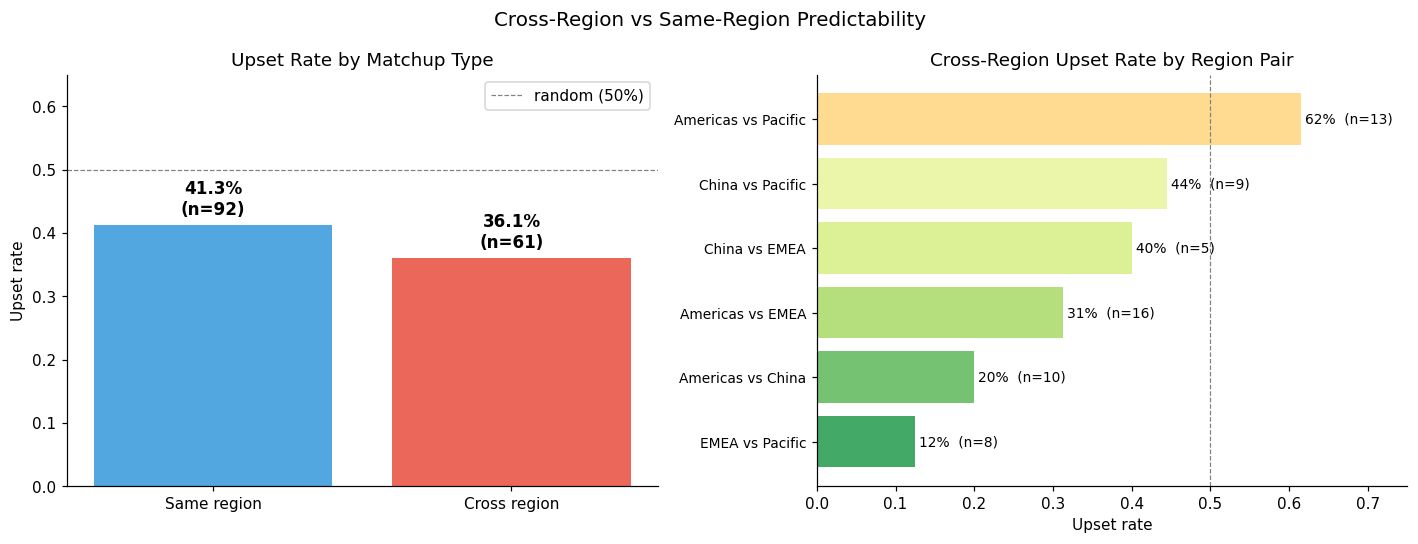

In [16]:
# Build a team → region map from ALL_MATCHES (scrape) and our ML_TEAMS REGION dict
# For non-ML teams we don't have region info, so restrict to matches where both teams
# have known regions.
ALL_TEAMS_REGION = dict(REGION)  # copy ML team regions

region_rows = []
for m in match_elos:
    ta, tb = m.get('team_a'), m.get('team_b')
    ra, rb = ALL_TEAMS_REGION.get(ta), ALL_TEAMS_REGION.get(tb)
    if not ra or not rb: continue

    diff   = m['elo_a_pre'] - m['elo_b_pre']
    win_a  = 1 if m.get('winner') == 0 else 0
    upset  = int((diff > 0 and win_a == 0) or (diff < 0 and win_a == 1)) if diff != 0 else None
    matchup = 'Same region' if ra == rb else 'Cross region'

    region_rows.append({
        'matchup':    matchup,
        'region_a':   ra,
        'region_b':   rb,
        'elo_diff':   diff,
        'win_a':      win_a,
        'upset':      upset,
    })

df_region = pd.DataFrame(region_rows)
df_nontie  = df_region[df_region['upset'].notna()].copy()

print(f"Matches with known regions: {len(df_region)}")
print(f"  Same region  : {(df_region['matchup']=='Same region').sum()}")
print(f"  Cross region : {(df_region['matchup']=='Cross region').sum()}")
print()

for mtype, grp in df_nontie.groupby('matchup'):
    ur = grp['upset'].mean()
    elo_acc = 1 - ur
    print(f"{mtype:14}  n={len(grp):3d}  upset_rate={ur:.1%}  elo_accuracy={elo_acc:.1%}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: upset rate by matchup type
ax = axes[0]
for i, (mtype, color) in enumerate([('Same region', '#3498db'), ('Cross region', '#e74c3c')]):
    grp = df_nontie[df_nontie['matchup'] == mtype]
    ur  = grp['upset'].mean()
    n   = len(grp)
    ax.bar(mtype, ur, color=color, alpha=0.85)
    ax.text(i, ur + 0.01, f'{ur:.1%}\n(n={n})', ha='center', va='bottom',
            fontsize=11, fontweight='bold')
ax.set_ylim(0, 0.65)
ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, label='random (50%)')
ax.set_ylabel('Upset rate')
ax.set_title('Upset Rate by Matchup Type')
ax.legend()

# Right: upset rate by region pair (cross-region only)
cross = df_nontie[df_nontie['matchup'] == 'Cross region'].copy()
cross['pair'] = cross.apply(lambda r: ' vs '.join(sorted([r['region_a'], r['region_b']])), axis=1)
pair_stats = cross.groupby('pair').agg(
    upset_rate=('upset', 'mean'), n=('upset', 'count')).reset_index().sort_values('upset_rate')

ax2 = axes[1]
cmap_vals = plt.cm.RdYlGn_r(pair_stats['upset_rate'].values)
bars = ax2.barh(range(len(pair_stats)), pair_stats['upset_rate'],
                color=cmap_vals, alpha=0.9)
for bar, (_, row) in zip(bars, pair_stats.iterrows()):
    ax2.text(row.upset_rate + 0.005, bar.get_y() + bar.get_height()/2,
             f'{row.upset_rate:.0%}  (n={row.n})', va='center', fontsize=9)
ax2.set_yticks(range(len(pair_stats)))
ax2.set_yticklabels(pair_stats['pair'], fontsize=9)
ax2.set_xlim(0, 0.75)
ax2.axvline(0.5, color='gray', linestyle='--', linewidth=0.8)
ax2.set_xlabel('Upset rate')
ax2.set_title('Cross-Region Upset Rate by Region Pair')

plt.suptitle('Cross-Region vs Same-Region Predictability', fontsize=13)
plt.tight_layout(); plt.show()

### 9g. Feature Correlation Summary

Bringing it all together: which of the available pre-match signals correlates most with winning?  
We compute point-biserial correlation (equivalent to Pearson for a binary outcome) for each candidate feature.

Matches with all features: 1339

Feature                              r     p-value     |r|
----------------------------------------------------------
Elo difference                   0.257      0.0000   0.257  ***
Recent form difference           0.208      0.0000   0.208  ***


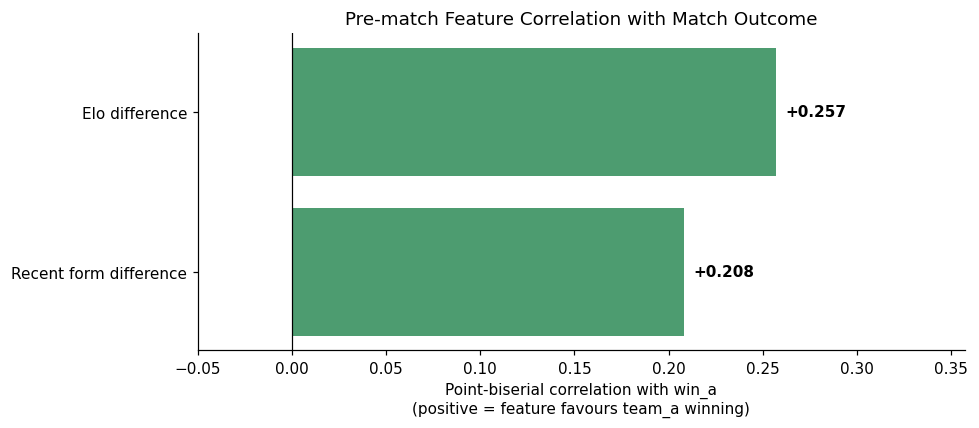


Interpretation:
  Elo difference:         captures long-run skill gap
  Recent form difference: captures momentum / current hot streak
  Both are independently correlated with winning —
  combining them should outperform either alone.


In [17]:
from scipy import stats as scipy_stats

# Build a combined feature frame for all matches where we have all signals
combo_rows = []

# Pre-compute form lookup from df_form (indexed by match metadata is tricky,
# so we rebuild it here cleanly)
form_lookup = {}   # (ta, tb, date) -> (form_diff)
for row in df_form.itertuples():
    # df_form was built from all matches, but index doesn't map to match id
    # so we can't directly join — instead we redo the merge via match_elos
    pass

# Rebuild combined frame directly
form_by_key = {}  # (ta, tb, date) -> form_diff
for m in sorted(ALL_MATCHES, key=lambda x: x.get('date', '')):
    ta, tb, date = m.get('team_a'), m.get('team_b'), m.get('date', '')
    if not ta or not tb or not date: continue
    fa = rolling_form(ta, date)
    fb = rolling_form(tb, date)
    if fa is not None and fb is not None:
        form_by_key[(ta, tb, date)] = fa - fb

for m in match_elos:
    ta, tb, date = m.get('team_a'), m.get('team_b'), m.get('date', '')
    if not ta or not tb or not date: continue
    win_a = 1 if m.get('winner') == 0 else 0

    elo_diff  = m['elo_a_pre'] - m['elo_b_pre']
    form_diff = form_by_key.get((ta, tb, date))
    if form_diff is None: continue

    combo_rows.append({
        'win_a':      win_a,
        'elo_diff':   elo_diff,
        'form_diff':  form_diff,
    })

df_combo = pd.DataFrame(combo_rows)
print(f"Matches with all features: {len(df_combo)}")

features = {
    'Elo difference':         'elo_diff',
    'Recent form difference': 'form_diff',
}

print(f"\n{'Feature':<30}  {'r':>6}  {'p-value':>10}  {'|r|':>6}")
print('-' * 58)
results = []
for label, col in features.items():
    r, p = scipy_stats.pointbiserialr(df_combo[col], df_combo['win_a'])
    results.append({'feature': label, 'r': r, 'abs_r': abs(r), 'p': p})
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
    print(f"{label:<30}  {r:>6.3f}  {p:>10.4f}  {abs(r):>6.3f}  {sig}")

df_results = pd.DataFrame(results).sort_values('abs_r', ascending=True)

fig, ax = plt.subplots(figsize=(9, 4))
colors_bar = ['seagreen' if r >= 0 else 'firebrick' for r in df_results['r']]
bars = ax.barh(df_results['feature'], df_results['r'], color=colors_bar, alpha=0.85)
for bar, r in zip(bars, df_results['r']):
    ax.text(r + (0.005 if r >= 0 else -0.005), bar.get_y() + bar.get_height()/2,
            f'{r:+.3f}', va='center', ha='left' if r >= 0 else 'right', fontsize=10, fontweight='bold')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Point-biserial correlation with win_a\n(positive = feature favours team_a winning)')
ax.set_title('Pre-match Feature Correlation with Match Outcome')
ax.set_xlim(min(df_results['r'].min() - 0.1, -0.05),
            max(df_results['r'].max() + 0.1, 0.05))
plt.tight_layout(); plt.show()

print("\nInterpretation:")
print("  Elo difference:         captures long-run skill gap")
print("  Recent form difference: captures momentum / current hot streak")
print("  Both are independently correlated with winning —")
print("  combining them should outperform either alone.")